In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import os
import numpy as np
import matplotlib.pyplot as plt 
import time
import scipy 
from PIL import Image

from scipy.constants import c, m_e, e, epsilon_0, hbar
from scipy.optimize import curve_fit

**Lanex Calibration (L1, L2) for setup before March 2026**


*Note:* Physics is commented, geometry not



In [ ]:
def electronPusher_carth(t, dt, E, B, Position, Momentum):
    """
    Calculate relativistic motion of charged particle in the presence 
    of electromagnetic field using 4th order Runge Kutta scheme by Tomas Kerepcky 
    Edited version for carthesian geometry
    Parameters
    ----------
    t : time vector.
    dt : time step.
    
    E : vector(3)
        Electric field.
    B : vector(3)
        Magnetic field.
    Position : function(3d)
        Initial electron position.
    Momentum : function(3d)
        Initial electron momentum.

    Returns
    -------
    Position, Momentum
        

    """
    import numpy as np
    from scipy.constants import c, m_e, e

    m       = m_e
    print('electron Pusher is starting ...')    
    # Electromagnetic field initialization
    Ex      = E[0]
    Ey      = E[1]
    Ez      = E[2]
    
    Bx      = B[0]
    By      = B[1]
    Bz      = B[2]
    
    # Momentum and position initialization
    rx      = np.zeros(np.size(t))
    ry      = np.zeros(np.size(t))
    rz      = np.zeros(np.size(t))
    px      = np.zeros(np.size(t)) 
    py      = np.zeros(np.size(t))
    pz      = np.zeros(np.size(t))
    
    rx[0]   = Position[0]
    ry[0]   = Position[1]
    rz[0]   = Position[2]
    px[0]   = Momentum[0]
    py[0]   = Momentum[1]
    pz[0]   = Momentum[2] 
    
    for n in range(np.size(t)-1): 
        p2      = px[n]**2 + py[n]**2 + pz[n]**2                                 #Square magnitude of momentum 
        vx      = (px[n]*c**2) / (np.sqrt(m**2*c**4 + p2*c**2))                      # xVelocity
        vy      = (py[n]*c**2) / (np.sqrt(m**2*c**4 + p2*c**2))                      # yVelocity 
        vz      = (pz[n]*c**2) / (np.sqrt(m**2*c**4 + p2*c**2))                      # zVelocity 
        #ry[n]      = np.sqrt(ry[n]**2 + rz[n]**2)
        
        pxk_1   = e * (Ex(rx[n],ry[n],t[n])        + vy             * Bz(rx[n],ry[n],t[n])          - vz             * By(rx[n],ry[n],t[n]))
        pxk_2   = e * (Ex(rx[n],ry[n],t[n]+dt/2)   +(vy+dt/2*pxk_1) * Bz(rx[n],ry[n],t[n]+dt/2)     -(vz+dt/2*pxk_1) * By(rx[n],ry[n],t[n]+dt/2))    
        pxk_3   = e * (Ex(rx[n],ry[n],t[n]+dt/2)   +(vy+dt/2*pxk_2) * Bz(rx[n],ry[n],t[n]+dt/2)     -(vz+dt/2*pxk_2) * By(rx[n],ry[n],t[n]+dt/2))
        pxk_4   = e * (Ex(rx[n],ry[n],t[n]+dt)     +(vy+dt*pxk_3)   * Bz(rx[n],ry[n],t[n]+dt)       -(vz+dt*pxk_3)   * By(rx[n],ry[n],t[n]+dt))
        
        
        pyk_1   = e * (Ey(rx[n],ry[n],t[n])        + vz             * Bx(rx[n],ry[n],t[n])          - vx             * Bz(rx[n],ry[n],t[n])) 
        pyk_2   = e * (Ey(rx[n],ry[n],t[n]+dt/2)   +(vz+dt/2*pyk_1) * Bx(rx[n],ry[n],t[n]+dt/2)     -(vx+dt/2*pyk_1) * Bz(rx[n],ry[n],t[n]+dt/2))    
        pyk_3   = e * (Ey(rx[n],ry[n],t[n]+dt/2)   +(vz+dt/2*pyk_2) * Bx(rx[n],ry[n],t[n]+dt/2)     -(vx+dt/2*pyk_2) * Bz(rx[n],ry[n],t[n]+dt/2))
        pyk_4   = e * (Ey(rx[n],ry[n],t[n]+dt)     +(vz+dt*pyk_3)   * Bx(rx[n],ry[n],t[n]+dt)       -(vx+dt*pyk_3)   * Bz(rx[n],ry[n],t[n]+dt))
       
        
        pzk_1   = e * (Ez(rx[n],ry[n],t[n])        + vx             * By(rx[n],ry[n],t[n])          - vy             * Bx(rx[n],ry[n],t[n]))
        pzk_2   = e * (Ez(rx[n],ry[n],t[n]+dt/2)   +(vx+dt/2*pzk_1) * By(rx[n],ry[n],t[n]+dt/2)     -(vy+dt/2*pzk_1) * Bx(rx[n],ry[n],t[n]+dt/2))    
        pzk_3   = e * (Ez(rx[n],ry[n],t[n]+dt/2)   +(vx+dt/2*pzk_2) * By(rx[n],ry[n],t[n]+dt/2)     -(vy+dt/2*pzk_2) * Bx(rx[n],ry[n],t[n]+dt/2))
        pzk_4   = e * (Ez(rx[n],ry[n],t[n]+dt)     +(vx+dt*pzk_3)   * By(rx[n],ry[n],t[n]+dt)       -(vy+dt*pzk_3)   * Bx(rx[n],ry[n],t[n]+dt))
        
        px[n+1] = px[n] + (1/6)*(pxk_1 + 2*pxk_2 + 2*pxk_3 + pxk_4)*dt        # New xMomentum
        py[n+1] = py[n] + (1/6)*(pyk_1 + 2*pyk_2 + 2*pyk_3 + pyk_4)*dt        # New yMomentum
        pz[n+1] = pz[n] + (1/6)*(pzk_1 + 2*pzk_2 + 2*pzk_3 + pzk_4)*dt        # New zMomentum
    
        rx[n+1] = rx[n] + vx*dt                                               # New xPosition
        ry[n+1] = ry[n] + vy*dt                                               # New yPosition
        rz[n+1] = rz[n] + vz*dt                                               # New zPosition
        #if np.mod(n,round((np.size(t)-1)/8))==0: print(n/(np.size(t)-1)*100,' % complete')
    print('Trajectory is calculated')
    return rx,ry,rz,px,py,pz



def E_fit(x, A, C, x0):
    """
    Function to fit the dispersion curve E(x).
    """
    return A / (x + x0) + C

<Figure size 1500x1200 with 0 Axes>

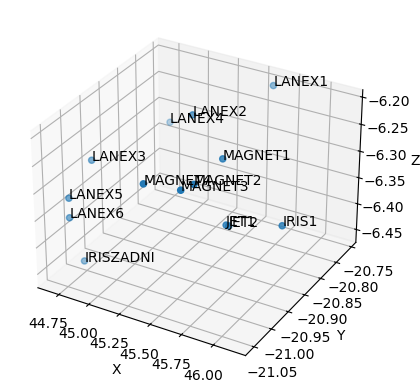

In [ ]:

plt.figure(figsize=(10, 8),dpi=150)


# coordinates 
points = { # 2nd measurement

    "IRISZADNI": (44.7356,-21.0015,-6.4569),
   

    "LANEX6": (44.6795,-21.0189,-6.3680),
    "LANEX5": (44.6801,-21.0189,-6.3314),
                


    "LANEX4": (44.8617,-20.8006,-6.2967),
    "LANEX3": (44.6840,-20.9590,-6.2942),
    "LANEX2": (45.3274,-20.8957,-6.2050),
    "LANEX1": (45.5957,-20.7569,-6.2065),
    "MAGNET4": (45.3983,-21.0525,-6.2386),
    "MAGNET3": (45.6495,-21.0395,-6.2405),
    "MAGNET2": (45.6860,-21.0169,-6.2407),
    "MAGNET1": (45.6815,-20.9361,-6.2404),
    "IRIS1": (46.1419,-20.9329,-6.3329),
    "JET2": (45.8248,-20.9696,-6.3334),
    "JET1": (45.8065,-20.9704,-6.3327),
}



points0 = { #1st measurement
    "LANEX2_2": (-6.1768, 31.5545, -6.2854),
    "LANEX2_1": (-6.0111, 31.5589, -6.2879),
    "LANEX4":   (-5.8071, 31.9011, -6.2635),
    "LANEX3":   (-5.8049, 31.9034, -6.1998),
    "LANEX2":   (-5.4426, 31.9829, -6.1751),
    "LANEX1":   (-5.7920, 31.8766, -6.1730),

    "MAG4":     (-5.7428, 32.0760, -6.2054),
    "MAG3":     (-5.5423, 32.2466, -6.2077),
    "MAG2":     (-5.4475, 32.1920, -6.2031),
    "MAG1":     (-5.4911, 32.2411, -6.2022),
}


# Extract coordinates
x = [p[0] for p in points.values()]
y = [p[1] for p in points.values()]
z = [p[2] for p in points.values()]
labels = list(points.keys())


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z)

# Annotate points
for i, label in enumerate(labels):
    ax.text(x[i], y[i], z[i], label)

# Axis labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

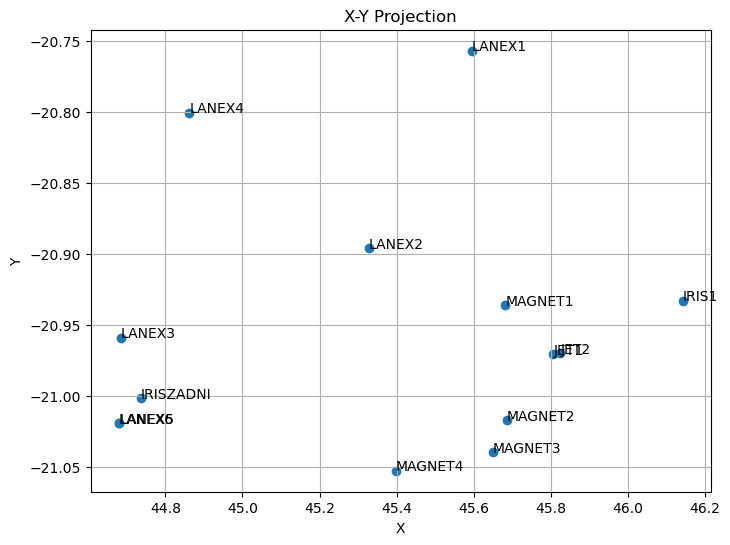

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(x, y)


for i, label in enumerate(labels):
    plt.text(x[i], y[i], label)


p1_name = "IRISZADNI"
p2_name = "IRIS1"




plt.xlabel("X")
plt.ylabel("Y")
plt.title("X-Y Projection")
plt.grid(True)


plt.show()

In [23]:
p1_name = "IRISZADNI"
p2_name = "IRIS1"
#p2_name="JET1"

xi1, yi1, zi1 = points[p1_name]
xi2, yi2, zi2 = points[p2_name]

#lanex 
Lx1,Ly1,Lz1 = points["LANEX1"]
Lx2,Ly2,Lz2 = points["LANEX2"]
Lx3,Ly3,Lz3 = points["LANEX3"]
Lx4,Ly4,Lz4 = points["LANEX4"]
Lx5,Ly5,Lz5 = points["LANEX5"]
Lx6,Ly6,Lz6 = points["LANEX6"]

Mx1,My1,Mz1 = points["MAGNET1"]
Mx2,My2,Mz2 = points["MAGNET2"]
Mx3,My3,Mz3 = points["MAGNET3"]
Mx4,My4,Mz4 = points["MAGNET4"]


In [24]:
def angle_between_lines(dmx1, dmy1, dmx2, dmy2):
    v1 = np.array([dmx1, dmy1])
    v2 = np.array([dmx2, dmy2])
    
    dot = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    
    cos_theta = dot / (norm1 * norm2)
    
    # Numerical safety (avoid acos domain error)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    
    angle_rad = np.arccos(cos_theta)
    angle_deg = np.degrees(angle_rad)
    
    print("Angle (radians):", angle_rad)
    print("Angle (degrees):", angle_deg)
    print()

    return angle_rad, angle_deg

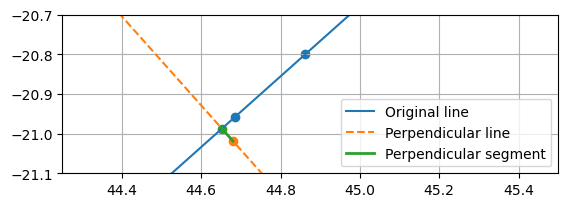

Intersection point: (44.65207365264431, -20.98745882623039)


In [ ]:
#POSITION OF THE EDGE OF 2ND LANEX

# Direction vector of original line
dx = Lx4 - Lx3
dy = Ly4 - Ly3

# ---- Compute intersection (foot of perpendicular) ----
# Using projection formula

# Vector from P1 to external point
px = Lx5 - Lx3
py = Ly5 - Ly3

# Projection scalar
t_proj = (px*dx + py*dy) / (dx*dx + dy*dy)

# Intersection point
x_int = Lx3 + t_proj * dx
y_int = Ly3 + t_proj * dy

# ---- Create lines for plotting ----
t = np.linspace(-10, 10, 200)

# Original line
x_line = Lx3 + dx * t
y_line = Ly3 + dy * t

# Perpendicular line (direction = -dy, dx)
perp_dx = -dy
perp_dy = dx
x_perp = Lx5 + perp_dx * t
y_perp = Ly5 + perp_dy * t



print("Intersection point:", (x_int, y_int))

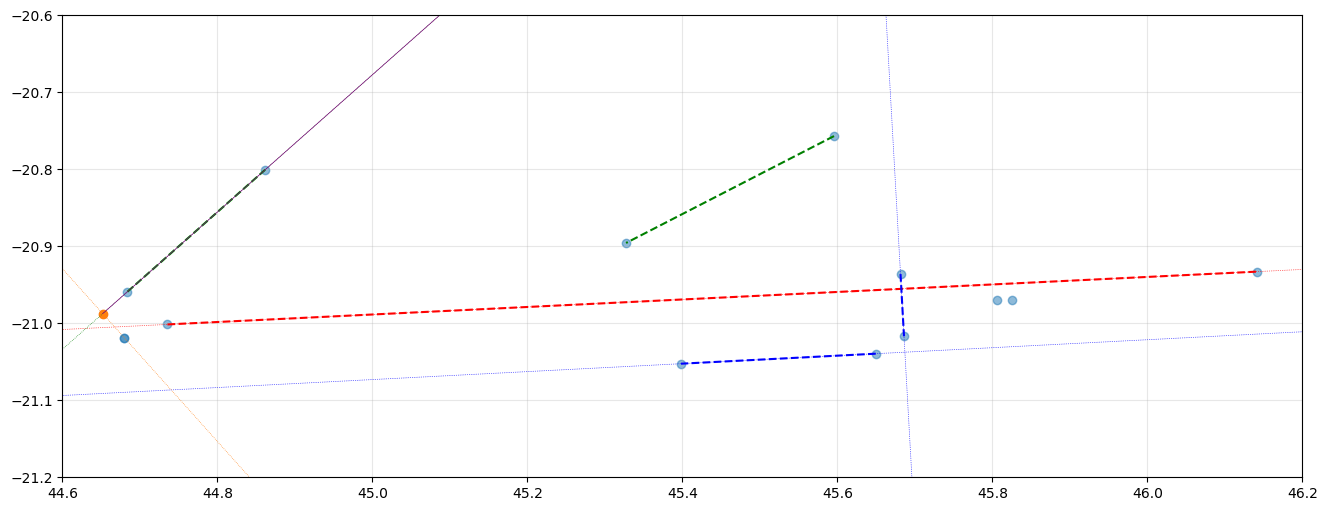

In [26]:
fig,ax = plt.subplots(figsize=(16, 6))
ax.scatter(x, y,alpha=0.5)
ax.plot([xi1, xi2], [yi1, yi2], 'r--',)  # Line between the two points

dx_oa = xi2 - xi1
dy_oa = yi2 - yi1
oa_x = xi1 + dx_oa * t
oa_y = yi1 + dy_oa * t
ax.plot(oa_x, oa_y, label="Optical axis",c='r',ls=':',lw=0.5)


ax.plot([Lx1, Lx2], [Ly1, Ly2], 'g--')  # Line between LANEX1 and LANEX2

ax.plot([Lx3, Lx4], [Ly3, Ly4], 'g--')  # Line between LANEX3 and LANEX4
ax.plot([Lx5, Lx6], [Ly5, Ly6], 'g--')  # Line between LANEX5 and LANEX6

ax.plot([Mx1, Mx2], [My1, My2], 'b--')  # Line between MAGNET1 and MAGNET2 
dmx1 = Mx2 - Mx1
dmy1 = My2 - My1
mline_x1 = Mx1 + dmx1 * t
mline_y1 = My1 + dmy1 * t
ax.plot(mline_x1, mline_y1, label="Magnet line",c='b',ls=':',lw=0.5)

ax.plot([Mx3, Mx4], [My3, My4], 'b--')  # Line between MAGNET3 and MAGNET4
dmx2 = Mx4 - Mx3

dmy2 = My4 - My3
mline_x2 = Mx3 + dmx2 * t
mline_y2 = My3 + dmy2 * t

ax.plot(mline_x2, mline_y2, label="Magnet line",c='b',ls=':',lw=0.5)

ax.plot(x_line, y_line, label="Original line",c='g',ls=':',lw=0.5)
ax.plot(x_perp, y_perp,c='C1',ls=':',lw=0.5 )
plt.scatter(x_int, y_int,c='C1',label="Lanex end")

ax.set_ylim(-21.2, -20.6)
ax.set_xlim(44.6, 46.2)

# Direction vector of your reference line
dx = x_line[-1] - x_line[0]
dy = y_line[-1] - y_line[0]

# Normalize (unit vector)
length = np.sqrt(dx**2 + dy**2)
ux = dx / length
uy = dy / length

# Projection length
L = 33

# New projected point
x_proj = x_int + ux * L
y_proj = y_int + uy * L

# Plot it
ax.plot([x_int, x_proj], [y_int, y_proj],
        c='purple', ls='-', lw=0.5, label='Projection (33)')


ax.grid(True,alpha=0.3)
#

In [27]:
print('Lanex2 x opotical axis:')
angle_rad_L2, angle_deg_L2 = angle_between_lines(dx_oa, dy_oa, dx, dy)


print('Magen x opotical axis:')
angle_rad, angle_deg = angle_between_lines(dx_oa, dy_oa, dmx1, dmy1)

print('Magnet1 x magnet2')
angle_rad, angle_deg = angle_between_lines(dmx2, dmy2, dmx1, dmy1)


Lanex2 x opotical axis:
Angle (radians): 0.6792959184329116
Angle (degrees): 38.920789166668854

Magen x opotical axis:
Angle (radians): 1.5639025832719222
Angle (degrees): 89.60501759108793

Magnet1 x magnet2
Angle (radians): 1.5747264560137255
Angle (degrees): 90.22517981717995



(44.5, 46.2)

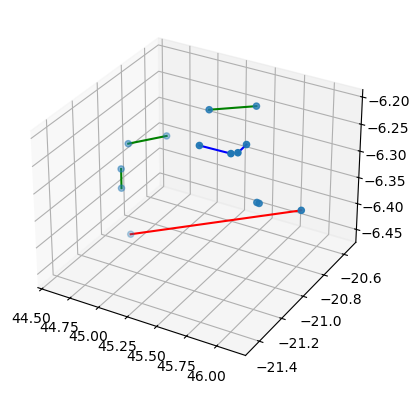

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(x, y, z)

ax.plot([xi1, xi2], [yi1, yi2], [zi1, zi2], 'r-')  # Line between the two points

ax.plot([Lx1, Lx2], [Ly1, Ly2], [Lz1, Lz2], 'g-')  # Line between LANEX1 and LANEX2
ax.plot([Lx3, Lx4], [Ly3, Ly4], [Lz3, Lz4], 'g-')  # Line between LANEX3 and LANEX4
ax.plot([Lx5, Lx6], [Ly5, Ly6], [Lz5, Lz6], 'g-')  # Line between LANEX5 and LANEX6

ax.plot([Mx1, Mx2], [My1, My2], [Mz1, Mz2], 'b-')  # Line between MAGNET1 and MAGNET2
ax.plot([Mx3, Mx4], [My3, My4], [Mz3, Mz4], 'b-')  # Line between MAGNET3 and MAGNET4

#ax.view_init(elev=45,azim=90 )

ax.set_ylim(-21.5, -20.5)
ax.set_xlim(44.5, 46.2)

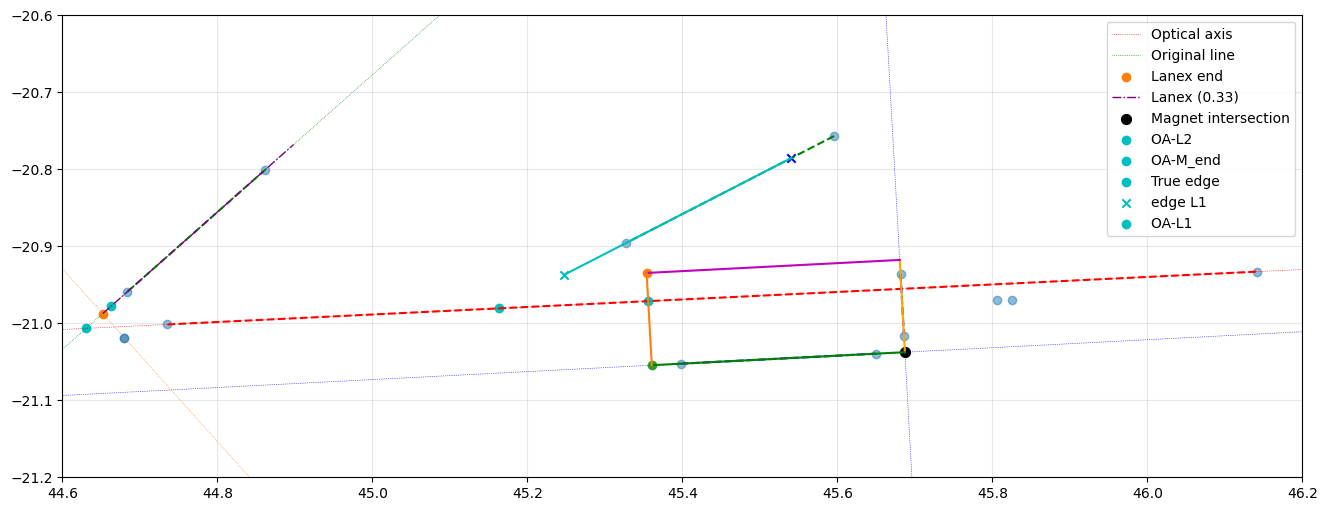

(45.54076699410719,)

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ helpers ------------------

def line_from_points(x1, y1, x2, y2, t):
    return x1 + (x2 - x1) * t, y1 + (y2 - y1) * t

def unit_vector(x1, y1, x2, y2):
    dx, dy = x2 - x1, y2 - y1
    norm = np.hypot(dx, dy)
    return dx / norm, dy / norm

def intersection(x1,y1,x2,y2, x3,y3,x4,y4):
    den = (x1-x2)*(y3-y4) - (y1-y2)*(x3-x4)
    if den == 0:
        return None
    px = ((x1*y2 - y1*x2)*(x3-x4) - (x1-x2)*(x3*y4 - y3*x4)) / den
    py = ((x1*y2 - y1*x2)*(y3-y4) - (y1-y2)*(x3*y4 - y3*x4)) / den
    return px, py

def segment_from_point(x0, y0, xt, yt, L):
    ux, uy = unit_vector(x0, y0, xt, yt)
    return x0 + ux * L, y0 + uy * L

# ------------------ figure ------------------

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(x, y, alpha=0.5)

# ------------------ optical axis ------------------

ax.plot([xi1, xi2], [yi1, yi2], 'r--')

oa_x, oa_y = line_from_points(xi1, yi1, xi2, yi2, t)
ax.plot(oa_x, oa_y, c='r', ls=':', lw=0.5, label="Optical axis")

# ------------------ lanex lines ------------------

for (x1,y1,x2,y2) in [(Lx1,Ly1,Lx2,Ly2),
                      (Lx3,Ly3,Lx4,Ly4),
                      (Lx5,Ly5,Lx6,Ly6)]:
    ax.plot([x1,x2],[y1,y2],'g--')

# ------------------ magnet lines ------------------

for (x1,y1,x2,y2) in [(Mx1,My1,Mx2,My2),
                      (Mx3,My3,Mx4,My4)]:
    ax.plot([x1,x2],[y1,y2],'b--')
    mx, my = line_from_points(x1,y1,x2,y2,t)
    ax.plot(mx, my, c='b', ls=':', lw=0.5)

# ------------------ original + perpendicular ------------------

ax.plot(x_line, y_line, c='g', ls=':', lw=0.5, label="Original line")
ax.plot(x_perp, y_perp, c='C1', ls=':', lw=0.5)

# store REAL Lanex end (important!)
x_lanex, y_lanex = x_int, y_int
ax.scatter(x_lanex, y_lanex, c='C1', label="Lanex end")

# ------------------ projection from Lanex ------------------

ux, uy = unit_vector(x_line[0], y_line[0], x_line[-1], y_line[-1])

L_proj = 0.33
x_proj = x_lanex + ux * L_proj
y_proj = y_lanex + uy * L_proj

ax.plot([x_lanex, x_proj], [y_lanex, y_proj],
        c='purple', ls='-.', lw=1., label='Lanex (0.33)')

# ------------------ magnet intersection ------------------

p = intersection(Mx1,My1, Mx2,My2, Mx3,My3, Mx4,My4)

if p:
    x_mag, y_mag = p
    ax.scatter(x_mag, y_mag, c='black', s=50, label="Magnet intersection")

    # ------------------ segments from intersection ------------------

    x_end1, y_end1 = segment_from_point(x_mag, y_mag, Mx1, My1, 0.12)
    x_end2, y_end2 = segment_from_point(x_mag, y_mag, Mx3, My3, 0.327)

    #ax.plot([x_mag, x_end1], [y_mag, y_end1], c='orange', lw=2)
    #ax.plot([x_mag, x_end2], [y_mag, y_end2], c='purple', lw=2)

    # ------------------ parallelogram ------------------

    x4 = x_end1 + (x_end2 - x_mag)
    y4 = y_end1 + (y_end2 - y_mag)

    ax.plot([x_mag, x_end1], [y_mag, y_end1], 'orange')
    ax.plot([x_mag, x_end2], [y_mag, y_end2], 'g')
    ax.plot([x_end1, x4], [y_end1, y4], 'm')
    ax.plot([x_end2, x4], [y_end2, y4], 'C1')

#m_up_edge = intersection(x_end2,y_end2, x4, y4, Lx3,Ly3, Lx4,Ly4)

#ax.scatter(m_up_edge[0],m_up_edge[1])
ax.scatter(x4,y4)
ax.scatter(x_end2,y_end2)
#m_down_edge = 

# intersection L2 OA

p_L2_axis = intersection(xi1,yi1, xi2,yi2, Lx3,Ly3, Lx4,Ly4)

p_M_end_axis = intersection(xi1,yi1, xi2,yi2, x_end2,y_end2, x4, y4)

ax.scatter(p_L2_axis[0], p_L2_axis[1], c='c',  label="OA-L2 ",alpha = 1.,)

ax.scatter(p_M_end_axis[0], p_M_end_axis[1], c='c',  label="OA-M_end ",alpha = 1.)


#true lanex edge 

L_small = 0.015 #lanex frame

x_offset = x_lanex + ux * L_small
y_offset = y_lanex + uy * L_small

ax.scatter(x_offset, y_offset, c='c', label='True edge') #edge of the lanexing screen


#L1

p_L1_mg = intersection(x_end1,y_end1,x4,y4,Lx1,Ly1,Lx2,Ly2)
#ax.scatter(p_L1_mg[0],p_L1_mg[1])

u_l1x,u_l1y = unit_vector(Lx1,Ly1,Lx2,Ly2)

r1 = 0.007293105504042506-0.015 # projection from old TS measurments
r2 = 0.33-r1


# L1 scinitilator edges -lanexing screen only 
x_proj1 = p_L1_mg[0] - u_l1x * r2 
y_proj1 = p_L1_mg[1] - u_l1y * r2


x_proj2 = p_L1_mg[0] + u_l1x * r1
y_proj2 = p_L1_mg[1] + u_l1y * r1


ax.scatter(x_proj1,y_proj1,c='b',marker='x')
ax.scatter(x_proj2,y_proj2,c='c',marker='x',label='edge L1')

ax.plot([x_proj1,x_proj2],[y_proj1,y_proj2],c='c')


p_OA_l1 = intersection(x_proj1,y_proj1,x_proj2,y_proj2, xi1,yi1, xi2,yi2,)

ax.scatter(p_OA_l1[0], p_OA_l1[1], c='c',  label="OA-L1 ",alpha = 1.,)


# ------------------ styling ------------------




ax.set_xlim(44.6, 46.2)
ax.set_ylim(-21.2, -20.6)
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()
x_proj1,

In [30]:
angle_rad_L1, angle_deg_L1 = angle_between_lines(x_mag-x_end2,y_mag-y_end2, (Lx1-Lx2), (Ly1-Ly2))
print(angle_deg-180)
r2+r1

Angle (radians): 0.4257108912399187
Angle (degrees): 24.39143736080015

-89.77482018282005


0.33

In [31]:
l_   = np.sqrt((p_L2_axis[0] - p_M_end_axis[0])**2 + (p_L2_axis[1] - p_M_end_axis[1])**2)
b_   = np.sqrt((p_L2_axis[0] - x_offset)**2 + (p_L2_axis[1] - y_offset)**2)
l_1  =  np.sqrt((p_OA_l1[0] - p_M_end_axis[0])**2 + (p_OA_l1[1] - p_M_end_axis[1])**2)
b_1  = np.sqrt((p_OA_l1[0] - x_proj2)**2 + (p_OA_l1[1] - y_proj2)**2)

m1_ = np.sqrt((x4 - p_M_end_axis[0])**2 + (y4 - p_M_end_axis[1])**2)
m2_ = np.sqrt((x_end2 - p_M_end_axis[0])**2 + (y_end2 - p_M_end_axis[1])**2)


print('## L1 ##')# divný
print('l = ',l_1)
print('b = ',b_1)
angle_rad_L1, angle_deg_L1 = angle_between_lines(x_mag-x_end2,y_mag-y_end2, (Lx1-Lx2), (Ly1-Ly2))
print()
print('## L2 ##')
print('l = ',l_)
print('b = ',b_)
print()
print('m1 = ',m1_)
print('m2 = ',m2_)
print('m1+m2 = ',m1_+m2_)

## L1 ##
l =  0.19297269731983466
b =  0.09508904080496693
Angle (radians): 0.4257108912399187
Angle (degrees): 24.39143736080015


## L2 ##
l =  0.7262410873630282
b =  0.04380103048194734

m1 =  0.03665823768586063
m2 =  0.08334176231413863
m1+m2 =  0.11999999999999926


In [32]:
dire           = r'c:\Dom\ELI\E2\calib_l2\test_in'            #directory for the data from tha lanex
dire_saving    = r'c:\Dom\ELI\E2\calib_l2\test_out'    #directory for saving

In [33]:
m2_+m1_

0.11999999999999926

In [ ]:
def calib(ll,bb,aangle,Emin = 150, Emax=1000,N_ele = 10,N_points = 5*10**4):
    N       = N_points                                 # number of timesteps -- should be enouth
    t,dt    = np.linspace(0, 5.5e-9,N,retstep=True)   # time vector and timestep -- [s]
    
    ######################################################
    ######################## Here ########################
    
    d       = 0.17          # [m] -- distance lanex-jet
    angle   = aangle  # angle lanex - optical axis
    l       = ll      # [m] -- distance from magnet to optical axis crossing with the "lanex axis"
    b       = bb+L_small         # [m] -- distance from optical axis crossing with the "lanex axis" to the lanex
    L_lanex = 0.3           # [m] -- length of lanex       
    L_magnet= 0.327         # [m] -- length of lanex
    
    ######################################################
    ######################################################
    
    crossing  = np.array([d + L_magnet + l,0] ) # position of optical axis crossing with the "lanex axis" to the lanex
    
    lanex_start = crossing - np.array([b*np.cos(angle),b*np.sin(angle)])
    lanex_end   = crossing - np.array([(b+L_lanex)*np.cos(angle),(b+L_lanex)*np.sin(angle)])
    
    fig, ax = plt.subplots(dpi=150)
    
    E_min       = Emin        #[MeV] -- min energy for calibration calculation
    E_max       = Emax      #[MeV] -- max energy for calibration calculation -- start with smaller than increase
    Numberof_el = N_ele        #number of electrons for simulation
    
    E_range = np.linspace(E_min*1e6*e , E_max*1e6*e, Numberof_el) # energy range -- in [J]
    
    
    
    def Bz_fce(x,y,L_magnet = L_magnet,w_up = m2_ ,w_down = m1_ ): 
        # test fuction for z component of mg field 
        if  d+L_magnet >x>d and w_up>y>-w_down: return   1.# [T]                               
        else: return 0
    
    #drawing of magnet
    plt.plot([d,d+L_magnet],          [m2_,  m2_],    c='grey')
    plt.plot([d,d+L_magnet],          [-m1_,-m1_],    c='grey')
    plt.plot([d,    d],               [m2_,  -m1_],   c='grey')
    plt.plot([d+L_magnet,d+L_magnet], [m2_,  -m1_],   c='grey')
    
    impacts_x =np.array([]) 
    impacts_y =np.array([])
    distances = np.array([]) 
    cur_ele = 0
    for E_el in E_range:
        cur_ele = cur_ele+1
        print('Calculating electrons: ',cur_ele,'/',Numberof_el)

        #Here -- intial conditions
        p0      = E_el/c # momentum in x-direction from kinectic energy 
        r0      = -0    #initial possition in x
        
        uhel = 0#-0.5/180*np.pi # angle between electron beam and main axis
        r_slide = 0*d*uhel    # change y initial possition -- for small angles only ('Taylor')
        
        Position    = np.array([r0,r_slide,0])                            #initial position
        Momentum    = np.array([p0*np.cos(uhel),p0*np.sin(uhel),0])       #initial momentum
        
        E       =  np.array([ lambda x,y,t:0, lambda x,y,t:0,  lambda x,y,t: 0]); # no El. field
        B       =  np.array([ lambda x,y,t:0, lambda x,y,t:0,  lambda x,y,t: Bz_fce(x,y)]); # homogenous Mg. field
        #B       =  np.array([ lambda x,y,t:0, lambda x,y,t:0,   lambda x,y,z,t: B(x, y, z)]);  # Yann method
        #to do -- proper interpolation 
            
        rx,ry,rz, px,py,pz = electronPusher_carth(t, dt, E, B, Position, Momentum) #trajectoy calculation
        
        for i in range(len(rx)): #calculation of electron impacts on lanex
            
            if np.arctan(np.abs(ry[i]/(crossing[0]-rx[i])))>angle:
                impacts_x = np.append(impacts_x,rx[i])
                impacts_y = np.append(impacts_y,ry[i])
                print('hit')
                break
            if i == len(rx)-1:
                impacts_x = np.append(impacts_x,np.nan)
                impacts_y = np.append(impacts_y,np.nan)

        plt.plot(rx,ry,c='blue',alpha=0.1) #plotting trajectory

        #for calculating final velocity and distance 
        traj_x = rx[rx<impacts_x[-1]]
        v_x= np.diff(traj_x)/dt
        dist_final = np.sum(v_x)*dt
        distances = np.append(distances,dist_final)
        
    #plotting lanex
    plt.plot([lanex_start[0],lanex_end[0]],[lanex_start[1],lanex_end[1]],c='black',alpha=0.67)
    
    #plotting optical axis
    plt.plot([0,crossing[0]*4],[0,0],ls=':',alpha=0.9,c='black')
    
    plt.scatter(impacts_x,impacts_y,c='red',marker='+')
    ax.set_ylabel(r'$y$ [m]', )
    ax.set_xlabel(r'$x$ [m]', )
    ax.set_aspect('equal')
    plt.xlim(-0.05,1.5)
    plt.ylim(-0.3,0.1)
    
    os.chdir(dire_saving)
    
    fig.savefig('lanex')
    
    
    fig, ax2 = plt.subplots(dpi=150)
    calib_dist = np.sqrt((impacts_x-lanex_start[0])**2 + (impacts_y-lanex_start[1])**2)
    
    X = calib_dist*1e2
    Y = E_range/e *1e-6
    
    popt, pcov = curve_fit(E_fit,     # function 
                     X,               # x-axis
                     Y ,              # y-axis
                     p0=[4e3,-1e2,1], # initial guess for params
                     maxfev=2400,
                     )
    print()
    print('#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-' )
    #print('#-#-#-#-#-#-#-#-#-# Fit pro d =',,' -#-#-#-#-#-#-#-#-' )
    
    print("A    =", popt[0], r'$\pm$', pcov[0,0]**0.5,' ( ',pcov[0,0]**0.5 /popt[0]*100,' %)') 
    print("C    =", popt[1], r'$\pm$', pcov[1,1]**0.5,' ( ',pcov[1,1]**0.5 /popt[1]*100,' %)') 
    print("x0   =", popt[2], r'$\pm$', pcov[2,2]**0.5,' ( ',pcov[2,2]**0.5 /popt[2]*100,' %)')
    print('#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-' )
    print()
    
    # equation of the fitted function with parrams
    rce   = fr'$ {popt[0]:.1f}/(x +{popt[2]:.2f} ) + ({popt[1]:.0f}) )$'
    
    x = np.linspace(0, 30,1000)
    y = E_fit(x,*popt)
    
    ax2.plot(calib_dist*1e2,E_range/e *1e-6,'rx',)
    ax2.plot(x,y,label=rce)
    ax2.set_ylabel(r'$E$ [MeV]', )
    ax2.set_xlabel(r'$l_{lanex}$ [cm]', )
    ax2.legend()
     
    #print(calib_dist*1e2,)
    #print(E_range/e *1e-6)
    print()
    print('Calibration Complete !')
    print('dt = ',dt ,' s')
    print('#-#-#-#-#-#-#-#-#-#-#-#-')
    
    
    
    fig.savefig('calib_curve')
    return popt,distances

In [52]:
angle_rad_L2

0.6792959184329116

Calculating electrons:  1 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  2 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  3 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  4 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  5 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  6 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  7 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  8 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  9 / 10
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  10 / 10
electron Pusher is starting ...
Trajectory is calculated
hit

#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-
A    = 5797.085149314776 $\pm$ 62

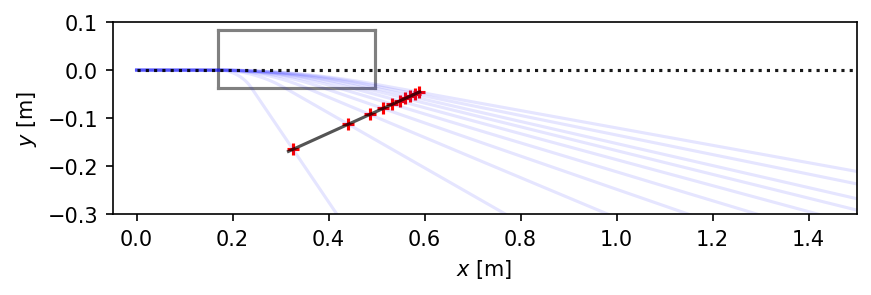

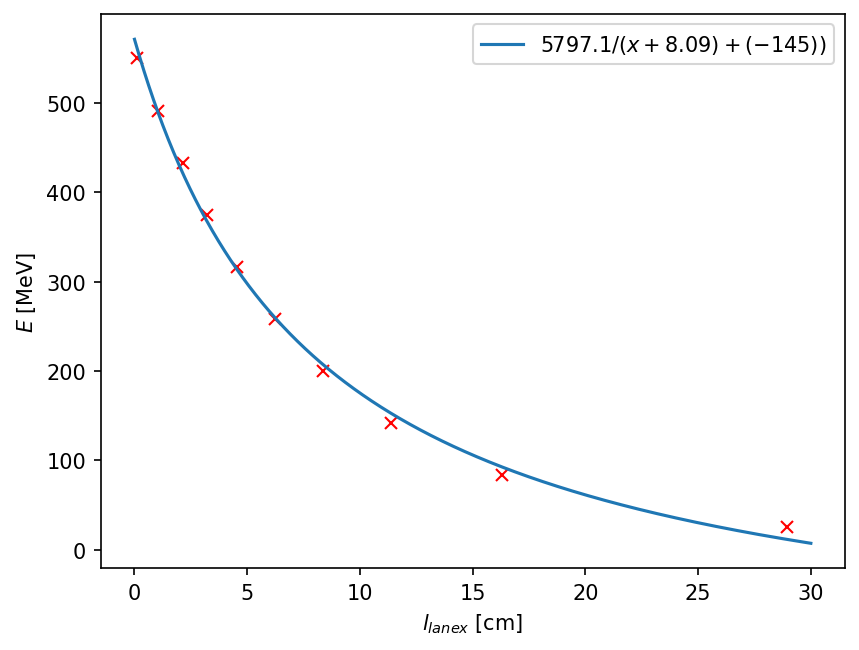

In [ ]:
calib1, distances1   = calib(l_1,b_1,angle_rad_L1,Emax=550,Emin=25,N_ele=4,N_points=10**5)

Calculating electrons:  1 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  2 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  3 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  4 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  5 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  6 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  7 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  8 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  9 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  10 / 40
electron Pusher is starting ...
Trajectory is calculated
hit
Calculating electrons:  11 / 40
electron Pusher is starting ...
Trajectory is c

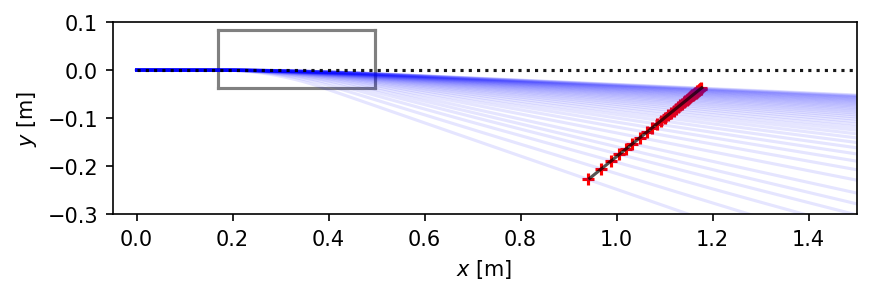

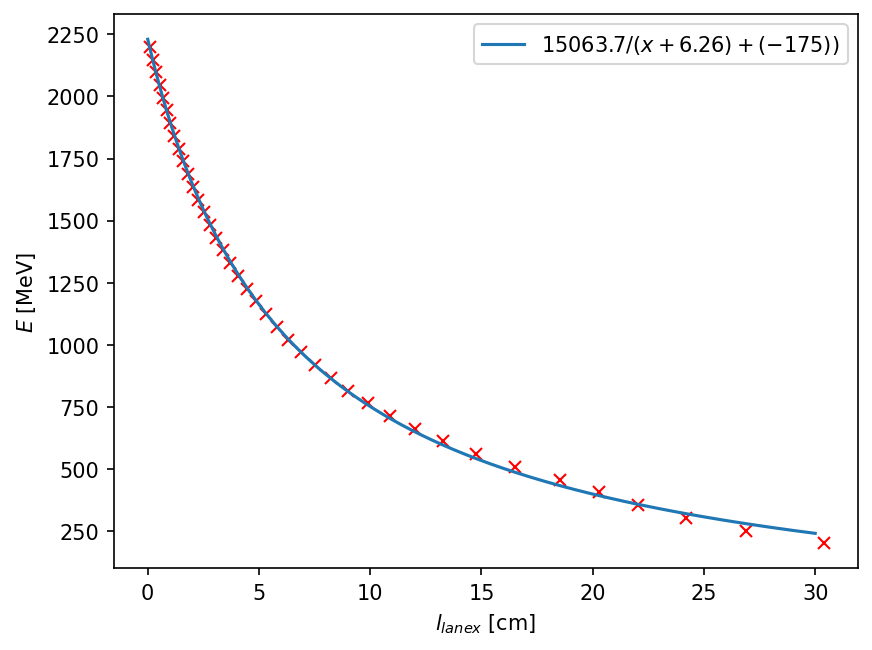

In [37]:
calib2, distances   = calib(l_,b_,angle_rad_L2,Emax=2200,Emin=200,N_points=10**5,N_ele=40)

In [38]:
print(calib1) #[7256.71667822 -196.195625      8.49950509]
print(calib2) 

[6929.05038146 -191.39216485    9.09416001]
[ 1.50637421e+04 -1.75419383e+02  6.26147281e+00]


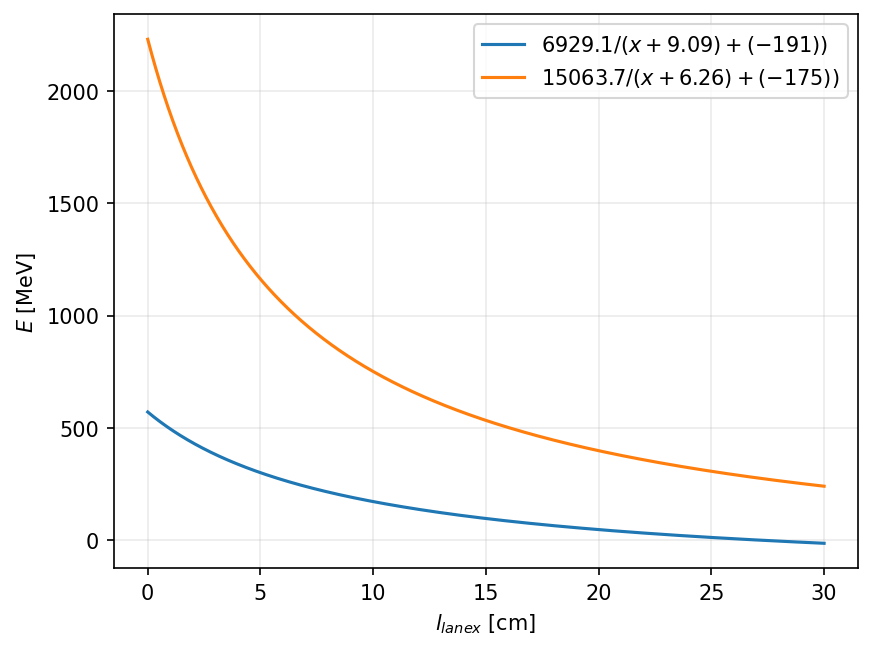

In [39]:
import numpy as np
import matplotlib.pyplot as plt 

# constant B = 0.95 T

def E_fit(x, A, C, x0):
    """
    Function to fit the dispersion curve E(x).
    """
    return A / (x + x0) + C

calib1_ = 6903.18483898, -190.15469795, 9.07788014             # L1
calib2_ = 1.47788538e+04, -1.61854943e+02, 6.17065733e+00     # L2

x = np.linspace(0, 30,1000)

y1 = E_fit(x,*calib1)
y2 = E_fit(x,*calib2)

fig,ax=plt.subplots(dpi=150)

rce1   = fr'$ {calib1[0]:.1f}/(x +{calib1[2]:.2f} ) + ({calib1[1]:.0f}) )$'
rce2   = fr'$ {calib2[0]:.1f}/(x +{calib2[2]:.2f} ) + ({calib2[1]:.0f}) )$'

ax.plot(x,y1,label=rce1)
ax.plot(x,y2,label=rce2)

ax.grid(True,alpha=0.25)

ax.set_ylabel(r'$E$ [MeV]', )
ax.set_xlabel(r'$l_{lanex}$ [cm]', )
ax.legend()

In [40]:
points0 = {
    "LANEX2_2": (-6.1768, 31.5545, -6.2854),
    "LANEX2_1": (-6.0111, 31.5589, -6.2879),
    "LANEX4":   (-5.8071, 31.9011, -6.2635),
    "LANEX3":   (-5.8049, 31.9034, -6.1998),
    "LANEX2":   (-5.4426, 31.9829, -6.1751),
    "LANEX1":   (-5.7920, 31.8766, -6.1730),

    "MAG4":     (-5.7428, 32.0760, -6.2054),
    "MAG3":     (-5.5423, 32.2466, -6.2077),
    "MAG2":     (-5.4475, 32.1920, -6.2031),
    "MAG1":     (-5.4911, 32.2411, -6.2022),
}



In [41]:
#L1

#lanex 
L1_x1,L1_y1,L_z1 = points0["LANEX1"]
L1_x2,L1_y2,L1_z2 = points0["LANEX2"]
L1_x3,L1_y3,L1_z3 = points0["LANEX3"]
L1_x4,L1_y4,L1_z4 = points0["LANEX4"]


M1_x1,M1_y1,M1_z1 = points0["MAG1"]
M1_x2,M1_y2,M1_z2 = points0["MAG2"]
M1_x3,M1_y3,M1_z3 = points0["MAG3"]
M1_x4,M1_y4,M1_z4 = points0["MAG4"]

L1_y1,L1_x1,L_z1 = points0["LANEX1"]
L1_y2,L1_x2,L1_z2 = points0["LANEX2"]
L1_y3,L1_x3,L1_z3 = points0["LANEX3"]
L1_y4,L1_x4,L1_z4 = points0["LANEX4"]


M1_y1,M1_x1,M1_z1 = points0["MAG1"]
M1_y2,M1_x2,M1_z2 = points0["MAG2"]
M1_y3,M1_x3,M1_z3 = points0["MAG3"]
M1_y4,M1_x4,M1_z4 = points0["MAG4"]

In [42]:
np.array(points0["MAG4"])-np.array(points0["MAG3"])

array([-0.2005, -0.1706,  0.0023])

In [43]:
print('Magnet1 x magnet2')
angle_rad, angle_deg = angle_between_lines(M1_x4-M1_x3, M1_y4-M1_y3, M1_x2-M1_x1, M1_y2-M1_y1)

# toto jest celkem naprd

Magnet1 x magnet2
Angle (radians): 1.591932224814623
Angle (degrees): 91.21099775274924



In [44]:
L1_ = line_from_points(L1_x1,L1_y1,L1_x2,L1_y2,t)


(31.876593578084726, -5.792021108346414)

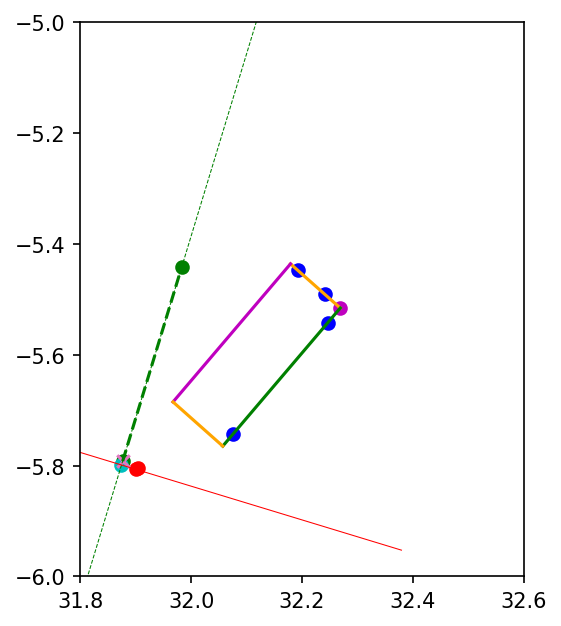

In [45]:
fig,ax=plt.subplots(dpi=150)

ax.scatter(L1_x1,L1_y1,c='g')
ax.scatter(L1_x2,L1_y2,c='g')
ax.scatter(L1_x3,L1_y3,c='r')
ax.scatter(L1_x4,L1_y4,c='r')

ax.plot([L1_x1,L1_x2],[L1_y1,L1_y2],c='g',ls='--')
ax.plot(L1_[0],L1_[1],c='g',ls='--',lw=0.5)

ax.scatter(M1_x1,M1_y1,c='b')
ax.scatter(M1_x2,M1_y2,c='b')
ax.scatter(M1_x3,M1_y3,c='b')
ax.scatter(M1_x4,M1_y4,c='b')

p_mg = intersection(M1_x1,M1_y1, M1_x2,M1_y2, M1_x3,M1_y3, M1_x4,M1_y4)
ax.scatter(p_mg[0],p_mg[1],c='m')


x0_end1, y0_end1 = segment_from_point(p_mg[0], p_mg[1], M1_x1, M1_y1, 0.12)
x0_end2, y0_end2 = segment_from_point(p_mg[0], p_mg[1], M1_x3, M1_y3, 0.327)

#ax.plot([x_mag, x_end1], [y_mag, y_end1], c='orange', lw=2)
#ax.plot([x_mag, x_end2], [y_mag, y_end2], c='purple', lw=2)

# ------------------ parallelogram ------------------

x1_4 = x0_end1 + (x0_end2 - p_mg[0])
y1_4 = y0_end1 + (y0_end2 - p_mg[1])

ax.plot([p_mg[0], x0_end1], [p_mg[1], y0_end1], 'orange')
ax.plot([p_mg[0], x0_end2], [p_mg[1], y0_end2], 'g')
ax.plot([x0_end1, x1_4], [y0_end1, y1_4], 'm')
ax.plot([x1_4, x0_end2], [y1_4, y0_end2], 'orange')




ux, uy = unit_vector(L1_x1, L1_y1, L1_x2, L1_y2)

# perpendicular unit vector
ux_perp = -uy
uy_perp = ux

t = np.linspace(-0.5, 0.5, 100)

x1_perp = L1_x4 + ux_perp * t
y1_perp = L1_y4 + uy_perp * t

ax.plot(x1_perp, y1_perp, c='r', lw=0.5, label='Perpendicular') 

p_edge = intersection(x1_perp[0],y1_perp[0],x1_perp[-1],y1_perp[-1],L1_x1, L1_y1, L1_x2, L1_y2)

ax.scatter(p_edge[0],p_edge[1],c='c')

p1_L1_mg = intersection(x0_end1,y0_end1,x1_4,y1_4,L1_x1, L1_y1, L1_x2, L1_y2)


r1 = np.sqrt((p1_L1_mg[0]-p_edge[0])**2+(p1_L1_mg[1]-p_edge[1])**2)



ax.scatter(p1_L1_mg[0],p1_L1_mg[1],c='C6',marker='x')

# ax.plot([x0_end2, x1_4], [y0_end2, x1_4], 'C1')
plt.gca().set_aspect('equal', adjustable='box')

ax.set_xlim(31.8,32.6)
ax.set_ylim(-6,-5)


p1_L1_mg

In [46]:
r1

0.007293105504042506

In [47]:
angle_rad, angle_deg = angle_between_lines(p_mg[0] - x0_end2, p_mg[1] - y0_end2, L1_x1-L1_x2, L1_y1-L1_y2)

Angle (radians): 2.731930426702064
Angle (degrees): 156.52808337340238



In [48]:
180 -angle_deg

23.47191662659762

In [49]:
(2**2+2**2)**0.5

2.8284271247461903